### Practical Work
Dataset: gfp_data 


In [1]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

from split.create_split import create_split

import mavenn

# LSTM model^
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

SEED = 42

2026-02-02 17:05:29.775099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Prepare Dataset: 
Der Trainingssatz, der den Offline-MBO-Algorithmen zur Verfügung gestellt wird, ist auf die unteren 50 % beschränkt, was zu einem sichtbaren Trainingssatz von 32898 Proben führt.

In [2]:
# Load dataset: GFP
df = mavenn.load_example_dataset('gb1')
df = df[['y', 'x']]
df.columns = ['binding_scores', 'sequence']
df['split'] = ['None'] * len(df)
print("data_loaded with shape:", df.shape)

# Encode amino acids into integers
AA_Alphabet = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_int = {aa: i for i, aa in enumerate(AA_Alphabet)}

def encode_protein(sequence):
    return np.array([aa_to_int.get(aa, 20) for aa in sequence.upper()])

df['encoded_sequence'] = df['sequence'].apply(encode_protein)

df['split'] = ['None'] * len(df)

df = create_split(df,
                  train_fraction=0.7,
                  k_seeds=50,
                  n_training_seeds=10,
                  fitness_percentile_cutoff=30.0,
                  training_radius_percentile=70.0,
                  random_state=SEED)

print("Dataset after splitting: ", df.shape)
df.head()

data_loaded with shape: (530737, 3)
Dataset after splitting:  (530737, 6)


,binding_scores,sequence,split,encoded_sequence,cluster,distance_to_seed
0,-3.145154,AAKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,"[0, 0, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1...",24,3
1,-1.867676,ACKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,"[0, 1, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1...",24,3
2,-5.270800,ADKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,"[0, 2, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1...",24,3
3,-5.979498,AEKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,"[0, 3, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1...",24,3
4,0.481923,AFKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,"[0, 4, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1...",24,3


In [3]:
# save dataset to csv
df.to_csv('GB1_data/GB1_dataset_split.csv', index=False)

In [4]:
train_df = df[df['split'] == 'train']

x = np.array(train_df['encoded_sequence'].tolist())
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values


X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = np.array([tf.one_hot(seq, depth=4).numpy().flatten() for seq in X_train])
X_val_onehot = np.array([tf.one_hot(seq, depth=4).numpy().flatten() for seq in X_val])


Shape of x: (14319, 55)
First row of x: [ 0 19  8  9  7  9 11  5  8 16  9  8  5  3 16 16 16  3  0 17  2  0  0 16
  0  3  8 17  4  8 13 19  0 11  2 11  5  5  2  5  3 18 16 19  2  2  0 16
  8 16  4 16 17 16  3]


2026-02-02 17:14:10.900485: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Next cell creates a dataframe with binding scores and one hot encoded sequences for the lookup task. 

In [5]:
# create dataframe for lookup task
test_df = df[df['split'] == 'test_c'] # use test_c for oracle evaluation

df_oracle = test_df[['encoded_sequence', 'binding_scores']] # try oracle with all sequences df instead of only train_df
x_oracle = np.array(df_oracle['encoded_sequence'].tolist())
df_oracle['one_hot_seq'] = [tf.one_hot(seq, depth=4).numpy().flatten() for seq in x_oracle]
df_oracle.drop(columns=df_oracle.columns[:-2], inplace=True)

# print highest value and lowest value in oracle
print(f'Oracle binding score range: {df_oracle["binding_scores"].min()} - {df_oracle["binding_scores"].max()}')

Oracle binding score range: -11.202243186187722 - 3.602644083396247


/tmp/ipykernel_26528/2964564990.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oracle['one_hot_seq'] = [tf.one_hot(seq, depth=4).numpy().flatten() for seq in x_oracle]
/tmp/ipykernel_26528/2964564990.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oracle.drop(columns=df_oracle.columns[:-2], inplace=True)


In [6]:
def oracle_lookup(one_hot_sequence):
    """Looks up the real binding score for a given one-hot encoded sequence."""
    flattened_seq = one_hot_sequence.flatten()
    match = df_oracle[df_oracle['one_hot_seq'].apply(lambda x: np.array_equal(x, flattened_seq))]
    if not match.empty:
        return match['binding_scores'].values[0]
    else:
        return 0.0  # no score if not found
    
def oracle_exists(one_hot_sequence):
    """Checks if a given one-hot encoded sequence exists in the oracle dataframe."""
    flattened_seq = one_hot_sequence.flatten()
    match = df_oracle[df_oracle['one_hot_seq'].apply(lambda x: np.array_equal(x, flattened_seq))]
    return not match.empty

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_onehot, y_train)
print(f'Best params: {rf_search.best_params_}')
print(f'Best CV R2: {rf_search.best_score_}')
print(f'Test R2: {r2_score(y_val, rf_search.predict(X_val_onehot))}')

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 500}
Best CV R2: 0.1350118179828936
Test R2: 0.1690129506546706


In [7]:
from scipy.stats import spearmanr
rf = RandomForestRegressor(n_estimators=500,
    max_depth=15,          # Limit tree depth
    min_samples_leaf=3,    # Require more samples per leaf
    min_samples_split=10,  # Require more samples to split
    max_features='sqrt',   # Use subset of features
    random_state=SEED
)

rf.fit(X_train_onehot, y_train)

# Evaluation just on a few samples from test set
#x_test = X_val.reshape(X_val.shape[0], y_train)

y_prediction = rf.predict(X_val_onehot)
r2 = r2_score(y_val, y_prediction)
mse = mean_squared_error(y_val, y_prediction)
spearmanr_corr, _ = spearmanr(y_val, y_prediction)
print(f'Spearmanr correlation: {spearmanr_corr}')
r2_train = r2_score(y_train, rf.predict(X_train_onehot))
print(f'R2 Score on train set: {r2_train}')
print(f'R2 Score: {r2}; MSE: {mse}')

Spearmanr correlation: 0.2786402357094684
R2 Score on train set: 0.07420209222958651
R2 Score: 0.06581020468571996; MSE: 0.697338788468939


In [8]:
import numpy as np
import tensorflow as tf

class SMW:

    def __init__(self, nucleotides):
        self.nucleotides = nucleotides
        self.n = len(nucleotides)

    def one_hot_encode(self, sequence):
        sequence_tensor = tf.one_hot(
            sequence, depth=4
        )
        sequence_numpy = sequence_tensor.numpy() 
        shape = sequence_numpy.shape[0] * sequence_numpy.shape[1]
        sequence_n_flat = sequence_numpy.reshape(1, shape)
        return sequence_n_flat

    def mutate_sequence(self, sequence, pos):
        sequence = list(sequence)
        if pos is None:
            pos = np.random.randint(0, len(sequence))
        # Get current nucleotide and possible mutations, make sure that nuc is different
        current_nucleotide = sequence[pos]
        possible_mutations = [nuc for nuc in self.nucleotides if nuc !=
                                current_nucleotide]
        # Replace nucleotide at position 
        new_nucleotide = np.random.choice(possible_mutations)
        sequence[pos] = new_nucleotide
        return sequence
        
    def walk(self, start_sequence, n_steps):
        current_seq = start_sequence
        history = []
        for step in range(n_steps):
            mutant = self.mutate_sequence(current_seq, None)
            mutant_one_hot = self.one_hot_encode(mutant)
            #mutant_fitness = fitness_function(mutant_one_hot)

            # Check if mutant is better than current
            # Yes: move to mutant
            #if mutant_fitness > current_fitness:
            current_seq = mutant
            #    current_fitness = mutant_fitness

            history.append(mutant_one_hot)
        return history


#### LSTM Model 

In [109]:
#Lstm model for sequence generation
model = Sequential()
model.add(LSTM(100, input_shape = (x.shape[1:])))
model.add(Dense(4, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.load_weights('lstm_sequence_model.h5')

model.summary()

def generate_sequence(seed_sequence, next_chars, max_sequence_len):
    for _ in range(next_chars):
        token_list = tf.one_hot(seed_sequence, depth=4)
        token_list = tf.reshape(token_list, (1, token_list.shape[0], token_list.shape[1]))
        predicted = model.predict(token_list, verbose=0)
        predicted_char = tf.argmax(predicted, axis=1).numpy()[0]
        seed_sequence.append(predicted_char)
        if len(seed_sequence) > max_sequence_len:
            seed_sequence = seed_sequence[1:]
    return seed_sequence

def generate_mutations(seed_sequence, n_mutations):
    mutations = []
    seed_sequence = seed_sequence[-1]
    for _ in range(n_mutations):
        mutated_sequence = generate_sequence(seed_sequence.copy(), next_chars=1, max_sequence_len=len(seed_sequence))
        mutations.append(mutated_sequence)
        seed_sequence = mutated_sequence[-1] # update seed to last generated character
    return mutations


/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,404 (165.64 KB)

 Trainable params: 42,404 (165.64 KB)

 Non-trainable params: 0 (0.00 B)

### Another Approach
1. One Mutation from Single Mutant Walker
2. Predict with RF
3. Normalize Predicted score to range 0-1
4. If score is higher -> save sequence else continue with old seed
5. Lookup real scores and plot trajectories

Starting seed sequence: [13 19  8  9  7  8 11  5  8 16  9  8  5  3 16 16 16  3  0 17  2  0  0 16
  0  3  8 17  4  8 13 19  0 11  2 11  5 17  2  5  3 18 16 19  2  2  0 16
  8 16 10 16 17 16  3] with binding score -7.88770542234304
Step 1/100, New best mutation with predicted score: -7.261093023617707


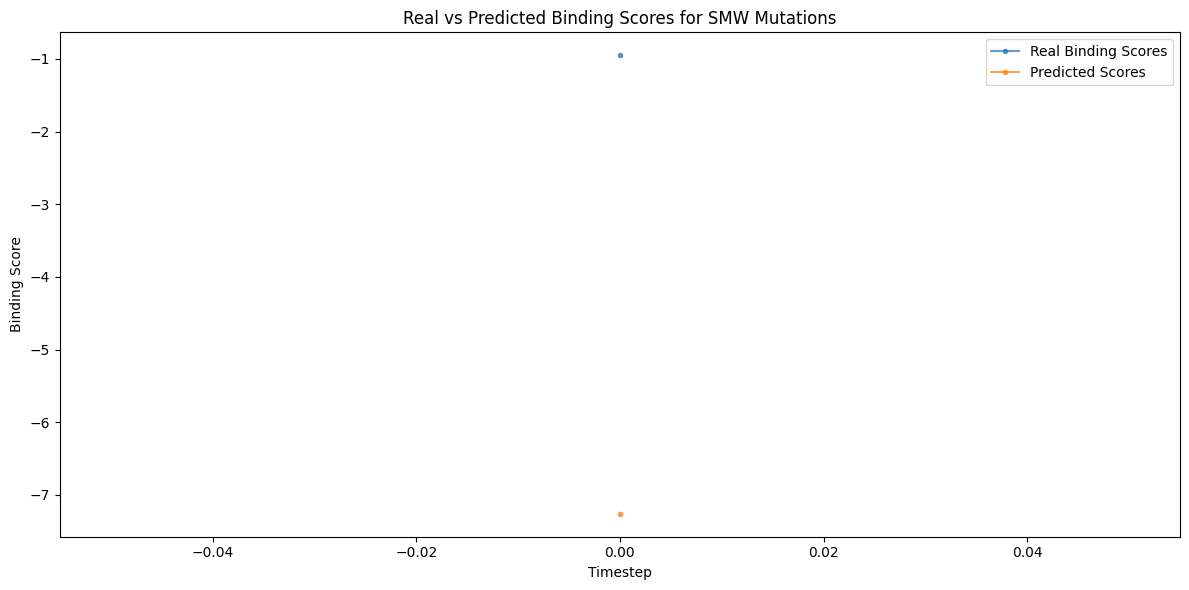

In [9]:
# Initialize SMW with nucleotides for proteins 0, ..., 20

smw = SMW(nucleotides=list(range(0, 20))) #nucleotides for proteins: 0, ..., 20
n_steps = 100
mutation_steps = 10

seen_sequences = X_train_onehot

#select a random seed sequence from training data
seed_sequence = X_train[0]
old_binding_score = y_train[0]
print(f'Starting seed sequence: {seed_sequence} with binding score {old_binding_score}')
#seed_sequence = tf.argmax(X_train[1300], axis=1).numpy().tolist()


values = {'mutation': [], 'predicted_score': []}

min_score = df_oracle['binding_scores'].min()
max_score = df_oracle['binding_scores'].max()

for i in range(n_steps):
    # Generate one mutation using SMW
    mutations = smw.walk(seed_sequence, mutation_steps)  # Get the first mutation
    # Check if mutation is new
    for idx, mutation in enumerate(mutations):
        already_seen = np.any(np.all(seen_sequences == mutation, axis=1))
        if not already_seen and oracle_exists(mutation):
            binding_score = rf.predict(mutation)
            if binding_score[0] > old_binding_score:
                # Update seed sequence
                seed_sequence = tf.argmax(tf.reshape(mutation, (mutation.shape[1]//4, 4)), axis=1).numpy().tolist()
                old_binding_score = binding_score[0]
                values['mutation'].append(mutation)
                # normalize binding score to 0-1 range based on oracle min/max
                #normalized_score = -(binding_score[0] - min_score) / (max_score - min_score)
                values['predicted_score'].append(binding_score[0])
                print(f'Step {i+1}/{n_steps}, New best mutation with predicted score: {binding_score[0]}')
            else:
                continue

# Lookup real binding score
df_values = pd.DataFrame(values)
df_values['real_score'] = df_values['mutation'].apply(oracle_lookup)
df_values['error'] = abs(df_values['predicted_score'] - df_values['real_score'])

# Plot results 
plt.figure(figsize=(12, 6))
plt.plot(df_values['real_score'], label='Real Binding Scores', alpha=0.7, marker='o', markersize=3)
plt.plot(df_values['predicted_score'], label='Predicted Scores', alpha=0.7, marker='o', markersize=3)
plt.xlabel('Timestep')
plt.ylabel('Binding Score')
plt.title('Real vs Predicted Binding Scores for SMW Mutations')
plt.legend()
plt.tight_layout()
plt.show()

Notes:
1. Testset A: spearman Correlation: 0.683, direction_agreement 66.7%
    Testset A > 0.5: spearman: 0.476, direction: 58.3%
    Testset A < 0.5: spearman: 0.413, direction: 58.3%
2. Testset B: spearman Correlation: 0.524, direction_agreement 58.3%
    Testset B > 0.5: spearman: 0.817 , direction: 55.6%
    Testset B < 0.5: spearman: -0.095, direction: 75.0%
3. Testset C: spearman Correlation: 0.764, direction_agreement 72.7

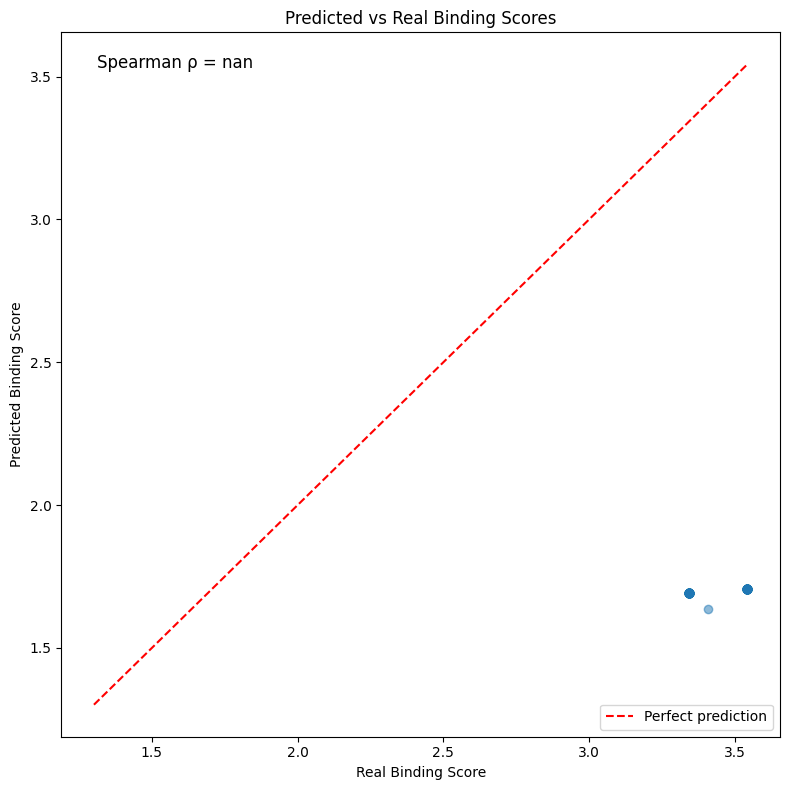

In [47]:
# Scatter plot shows correlation regardless of absolute values
plt.figure(figsize=(8, 8))
plt.scatter(df_values['real_score'], df_values['predicted_score'], alpha=0.5)
plt.plot([df_values['real_score'].min(), df_values['real_score'].max()], 
         [df_values['real_score'].min(), df_values['real_score'].max()], 
         'r--', label='Perfect prediction')
plt.xlabel('Real Binding Score')
plt.ylabel('Predicted Binding Score')
plt.title('Predicted vs Real Binding Scores')
plt.legend()

# Add Spearman correlation to plot
from scipy.stats import spearmanr
corr, _ = spearmanr(df_values['real_score'], df_values['predicted_score'])
plt.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}', transform=plt.gca().transAxes, fontsize=12)
plt.tight_layout()
plt.show()

Direction agreement: 99.0%


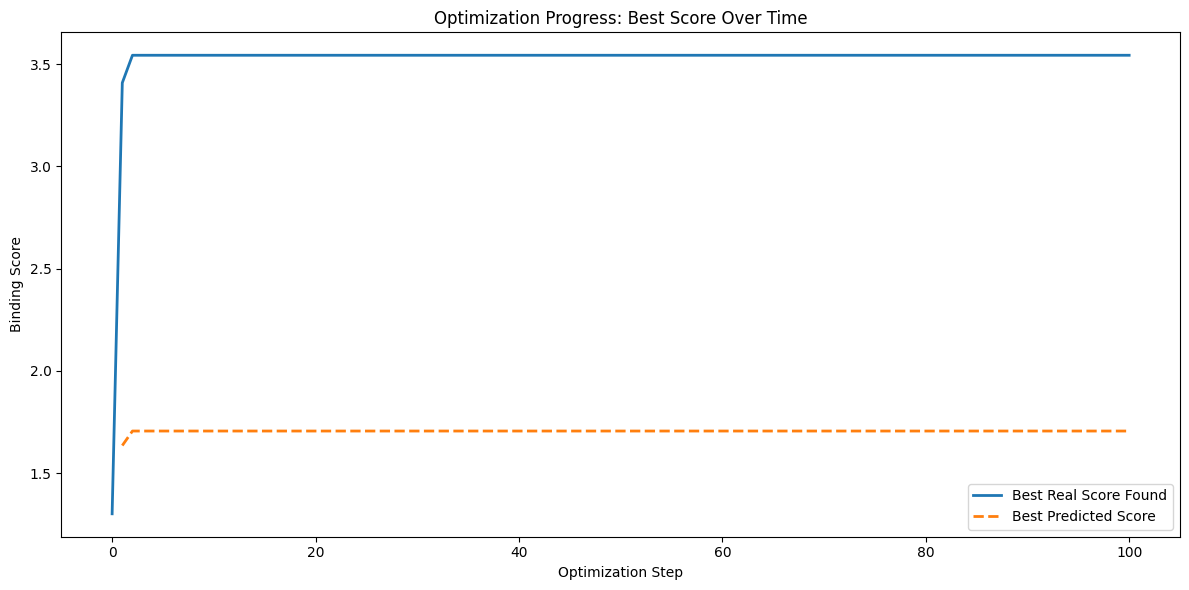

In [48]:
# What matters: Did real scores also improve when predicted scores improved?
df_values['real_score_improved'] = df_values['real_score'].diff() > 0
df_values['pred_score_improved'] = df_values['predicted_score'].diff() > 0

# How often did both agree on direction?
agreement = (df_values['real_score_improved'] == df_values['pred_score_improved']).mean()
print(f'Direction agreement: {agreement:.1%}')

# Plot cumulative real score improvement
plt.figure(figsize=(12, 6))
plt.plot(df_values['real_score'].cummax(), label='Best Real Score Found', linewidth=2)
plt.plot(df_values['predicted_score'].cummax(), label='Best Predicted Score', linewidth=2, linestyle='--')
plt.xlabel('Optimization Step')
plt.ylabel('Binding Score')
plt.title('Optimization Progress: Best Score Over Time')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
from sklearn.linear_model import LinearRegression

# Use validation set to learn a calibration mapping
y_val_pred = rf.predict(X_val_onehot)

# Fit linear calibration: real = a * predicted + b
calibrator = LinearRegression()
calibrator.fit(y_val_pred.reshape(-1, 1), y_val)

# Apply calibration to your results
df_values['calibrated_score'] = calibrator.predict(
    np.array(df_values['predicted_score']).reshape(-1, 1)
)

# Plot calibrated results
plt.figure(figsize=(12, 6))
plt.plot(df_values['real_score'].values, label='Real Binding Scores', marker='o', markersize=3)
plt.plot(df_values['calibrated_score'].values, label='Calibrated Predictions', marker='o', markersize=3)
plt.xlabel('Step')
plt.ylabel('Binding Score')
plt.title('Real vs Calibrated Binding Scores')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Calibration: predicted * {calibrator.coef_[0]:.3f} + {calibrator.intercept_:.3f}')

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Plot the trajcectories into a Scatterplot

In [50]:
from matplotlib.patches import FancyArrowPatch
import umap
from sklearn.preprocessing import StandardScaler

# Prepare all sequences for embedding (oracle + trajectory)
X_oracle_onehot = np.vstack(df_oracle['one_hot_seq'].values)
X_trajectory = np.vstack(df_values['mutation'].values)

# Combine for consistent embedding
X_combined = np.vstack([X_oracle_onehot, X_trajectory])

# Fit UMAP on combined data
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Split back
n_oracle = len(X_oracle_onehot)
embedding_oracle = embedding[:n_oracle]
embedding_trajectory = embedding[n_oracle:]

# Get scores for coloring
oracle_scores = df_oracle['binding_scores'].values
trajectory_real_scores = df_values['real_score'].values


fig, ax = plt.subplots(figsize=(12, 10))


# Background landscape
scatter = ax.scatter(
    embedding_oracle[:, 0], 
    embedding_oracle[:, 1], 
    c=oracle_scores, 
    cmap='viridis', 
    alpha=0.3, 
    s=10
)
plt.colorbar(scatter, label='Binding Score')

# Draw arrows between consecutive trajectory points
for i in range(len(embedding_trajectory) - 1):
    ax.annotate(
        '', 
        xy=(embedding_trajectory[i+1, 0], embedding_trajectory[i+1, 1]),
        xytext=(embedding_trajectory[i, 0], embedding_trajectory[i, 1]),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7)
    )

# Trajectory points colored by score
ax.scatter(
    embedding_trajectory[:, 0], 
    embedding_trajectory[:, 1], 
    c=trajectory_real_scores,
    cmap='viridis',
    edgecolors='red',
    linewidths=1.5,
    s=80,
    zorder=5
)

# Start and end markers
ax.scatter(embedding_trajectory[0, 0], embedding_trajectory[0, 1], 
           c='lime', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'Start (score={trajectory_real_scores[0]:.3f})', zorder=10)
ax.scatter(embedding_trajectory[-1, 0], embedding_trajectory[-1, 1], 
           c='red', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'End (score={trajectory_real_scores[-1]:.3f})', zorder=10)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Optimization Trajectory on Fitness Landscape')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fitness_landscape_trajectory_testset_B_larger0.5.png', dpi=150)
plt.show()

KeyError: 'mutation'